## Tutorial: Measuring Radial Velocities for SB1s with MINATO's `ravel` Module


This hands‑on notebook will guide you through fitting a single spectral line in a single‑lined binary (SB1) to extract its radial velocity (RV). We'll use the `ravel` module from MINATO.

---

### 1. Prerequisites

Before starting, ensure you have:

- A Python 3.9+ environment
- MINATO installed
- Dependencies (see installation notes)
- The SB1 synthetic spectra provided or your own spectra

---

### 2. Import Modules and Functions


In [35]:
import numpy as np
import pandas as pd
from glob import glob
import matplotlib.pyplot as plt
from IPython.display import Image, display
import sys
sys.path.append('/Users/villasenor/science/github/jvillasr/MINATO')
import importlib
from minato import ravel, myRC
importlib.reload(ravel)

JAX 64-bit enabled: True


<module 'minato.ravel' from '/Users/villasenor/science/github/jvillasr/MINATO/minato/ravel.py'>

---

### 3. Load a Spectrum

Replace `fits_file` and `instrument` with your data path and instrument tag.

In [36]:
data_path = 'synth_spectra/SB1/'
spec_files = sorted(glob(data_path+'*SB1*'))
# spec_files = [x.replace(data_path, '') for x in spec_files]
results_path = 'SB1/'
# Read wavelength and flux
# wave, flux = read_fits(fits_file)

# Estimate per‑pixel flux error over continuum regions
# flux_err = compute_flux_err(wave, flux, wave_region=(5000, 6000))
print(data_path)
spec_files

synth_spectra/SB1/


['synth_spectra/SB1/synthetic_SB1_01.txt',
 'synth_spectra/SB1/synthetic_SB1_02.txt',
 'synth_spectra/SB1/synthetic_SB1_03.txt',
 'synth_spectra/SB1/synthetic_SB1_04.txt',
 'synth_spectra/SB1/synthetic_SB1_05.txt',
 'synth_spectra/SB1/synthetic_SB1_06.txt',
 'synth_spectra/SB1/synthetic_SB1_07.txt',
 'synth_spectra/SB1/synthetic_SB1_08.txt',
 'synth_spectra/SB1/synthetic_SB1_09.txt',
 'synth_spectra/SB1/synthetic_SB1_10.txt',
 'synth_spectra/SB1/synthetic_SB1_11.txt',
 'synth_spectra/SB1/synthetic_SB1_12.txt']

Let's inspect the spectra. We created 12 noise spectra (S/N=30) with R=5000 and vsini=100 km/s

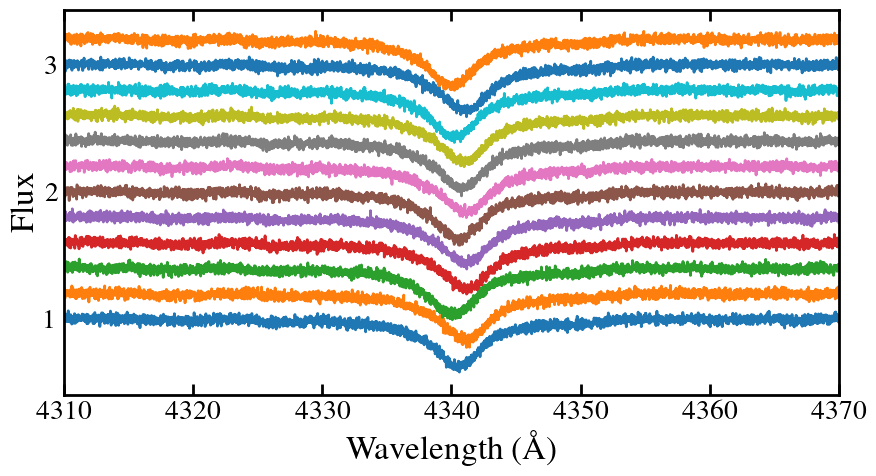

In [37]:
# Read the spectrum
wavelengths, fluxes, f_errors, names, jds = ravel.read_spectra(spec_files, data_path, file_type='txt')

fig, ax = plt.subplots(figsize=(10, 5))
for i, (wave, flux) in enumerate(zip(wavelengths, fluxes)):
    ax.plot(wave, flux + i*0.2, '-', lw=2)
ax.set_xlabel('Wavelength (Å)')
ax.set_ylabel('Flux')
# ax.set_xlim(4000, 4600)
ax.set_xlim(4310, 4370)
plt.show()
plt.close()

---

### 4. Setup `ravel.SLfit`

We need to define the spectral lines we want to fit

In [27]:
lines = [4026, 4089, 4102, 4144, 4340, 4388, 4471, 4542, 4553]

In [28]:
lines_dictionary = ravel.setup_line_dictionary()
lines_dictionary

{4102: {'region': [4080, 4122],
  'centre': [4102.8991, 0.0024],
  'air': [4101.7414, 0.0024],
  'wid_ini': 6,
  'title': 'H$\\delta$'},
 4340: {'region': [4316, 4366],
  'centre': [4341.691, 0.003],
  'air': [4340.471, 0.003],
  'wid_ini': 7,
  'title': 'H$\\gamma$'},
 4861: {'region': [4836, 4871],
  'centre': [4862.691, 0.003],
  'air': [4861.333, 0.003],
  'wid_ini': 6,
  'title': 'H$\x08eta$'},
 6562: {'region': [6538, 6579],
  'centre': [6564.632, 0.007],
  'air': [6562.819, 0.007],
  'wid_ini': 6,
  'title': 'H$\x07lpha$'},
 4009: {'region': [4001, 4014],
  'centre': [4010.3899037, 1.1e-06],
  'air': [4009.256516, 2e-05],
  'wid_ini': 3,
  'title': 'He I $\\lambda$4009'},
 4026: {'region': [4013, 4039],
  'centre': [4027.36003, 4e-05],
  'air': [4026.22221, 4e-05],
  'wid_ini': 3,
  'title': 'He I $\\lambda$4026'},
 4121: {'region': [4114, 4126],
  'centre': [4121.99776, 2e-05],
  'air': [4120.83518, 2e-05],
  'wid_ini': 3,
  'title': 'He I $\\lambda$4121'},
 4144: {'region': [4

And we run `SLfit` to perform the fit

In [34]:
star_path = ravel.SLfit(spec_files, data_path=data_path, save_path=results_path, lines=lines, SB2=False, file_type='txt')



*******************************************************************************
******************           Spectral Line fitting           ******************
*******************************************************************************

*** SB2 set to: False ***


*** Fitting lines ***
---------------------
Lines to be fitted: [4026, 4089, 4102, 4144, 4340, 4388, 4471, 4542, 4553]
Fitting all lines simultaneously
Number of lines: 9
Number of epochs: 12


/Users/villasenor/science/github/jvillasr/MINATO/minato/ravel.py:1086: UserWarning: There are not enough devices to run parallel chains: expected 4 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(4)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(kernel, num_warmup=1000, num_chains=4, num_samples=2000)
sample: 100%|██████████| 3000/3000 [00:38<00:00, 78.85it/s, 15 steps of size 2.06e-01. acc. prob=0.92] 


Plotting fits for line: 4026
Plotting fits for line: 4089
Plotting fits for line: 4102
Plotting fits for line: 4144
Plotting fits for line: 4340
Plotting fits for line: 4388
Plotting fits for line: 4471
Plotting fits for line: 4542
Plotting fits for line: 4553


You can now see the results of the fit in your `results_path` directory. Here is one of the plots stored by `SLfit`, in this case the H&gamma; fit

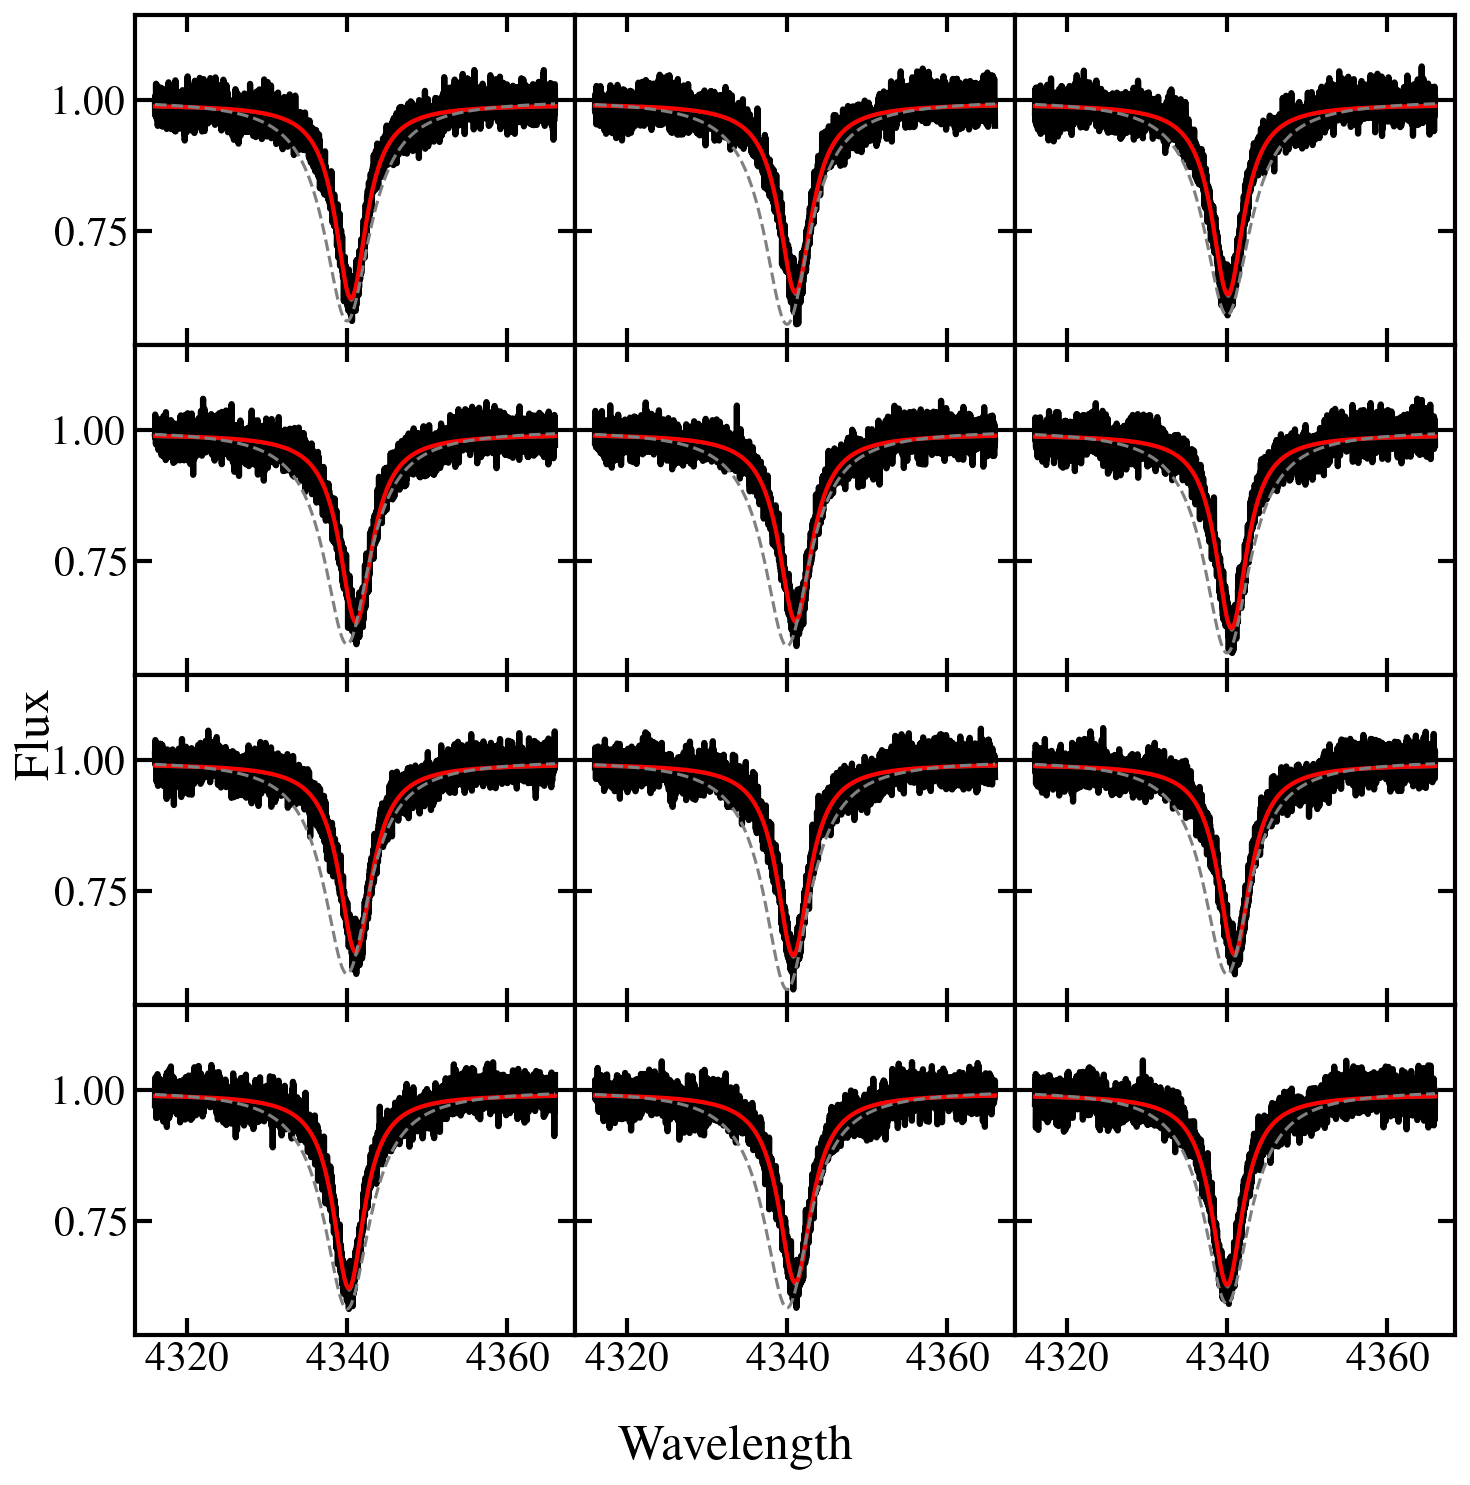

In [12]:
display(Image(
    filename='SB1/4340_fits.png',
    width=600  # pixels
))

---

### 5. Compute radial velocities

We'll now compute the RVs from the results of `SLfit`

In [13]:
rv_analysis = ravel.GetRVs('fit_values.csv', star_path, star_path+'JDs.txt', lines_ok_thrsld=4, rm_epochs=False)
results = rv_analysis.compute()

Using default line dictionary from ravel.setup_line_dictionary().


KeyError: 'cen1_er'

We can now display `results` which is a dataframe containing the RVs, or alternatively, load the resulting RVs from the saved file to compare with the *true* RVs

In [16]:
# rvs = pd.read_csv(star_path+'RVs1.txt', sep='\s+')
rvs = pd.read_csv(star_path+'fit_values.csv')
rvs

,epoch,MJD,mean_rv,mean_rv_er,posterior_method
0,synth_spectra/synthetic_SB1_01,NaN,3.926511,2.475132,HDI
1,synth_spectra/synthetic_SB1_02,NaN,45.898500,2.563778,HDI
2,synth_spectra/synthetic_SB1_03,NaN,-21.769167,2.562052,HDI
3,synth_spectra/synthetic_SB1_04,NaN,47.144596,2.591801,HDI
4,synth_spectra/synthetic_SB1_05,NaN,43.573718,2.529630,HDI
5,synth_spectra/synthetic_SB1_06,NaN,8.535887,2.632271,HDI
6,synth_spectra/synthetic_SB1_07,NaN,46.373328,2.462423,HDI
7,synth_spectra/synthetic_SB1_08,NaN,23.669960,2.486014,HDI
8,synth_spectra/synthetic_SB1_09,NaN,33.710923,2.436990,HDI
9,synth_spectra/synthetic_SB1_10,NaN,-16.197021,2.500088,HDI


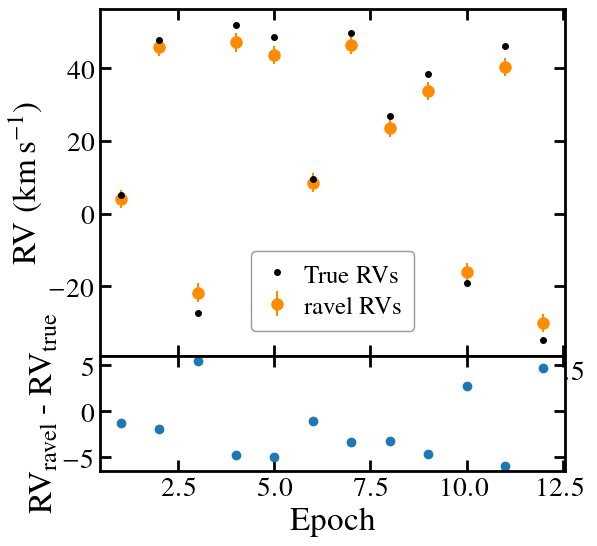

In [18]:
rvs_true = [  5.24133845,  47.8077272 , -27.27375349,  51.90167827,
         48.51521101,   9.63176316,  49.69269188,  26.89443541,
         38.38362392, -19.01153521,  46.19572543, -34.73351377]

fig, ax = plt.subplots(ncols=1, nrows=2, figsize=(6, 6), gridspec_kw={'hspace': 0., 'height_ratios': [3, 1]})
ax[0].errorbar(np.arange(12)+1, rvs['mean_rv'], rvs['mean_rv_er'], fmt='o', ms=8, color='darkorange', label='ravel RVs', zorder=0)
ax[0].plot(np.arange(12)+1, rvs_true, '.', ms=8, c='k', label='True RVs', zorder=1)
ax[1].plot(np.arange(12)+1, rvs['mean_rv'] - rvs_true, 'o', label='ravel RVs - True RVs')
ax[0].legend()
ax[0].set(ylabel='RV (km\,s$^{-1}$)')
ax[1].set(xlabel='Epoch', ylabel=r'RV$_{\rm ravel}$ - RV$_{\rm true}$')
plt.show()
plt.close()

**Note**: even though this simulated system is an SB1 where we don't see the contribution from the companion, we can clearly see the companion's effect in the RVs, with shifts of up to 5 km/s from the true RVs of the primary star. For this example we have use **M1=18.6 Msun, q=0.39, P=31.5 d and e=0.05**.

---

### 6. Orbital period search

We can also use ravel to search for the period of the system. Here we use a wrapper around Astropy's Lomb-Scargle periodogram 

In [22]:
ls_results = ravel.lomb_scargle(rvs, star_path, print_output=True, plots=True, SB2=False)

ValueError: cannot convert float NaN to integer

`ravel` will generate a new directory `/LS` in `star_path`, where we can check the periodogram:

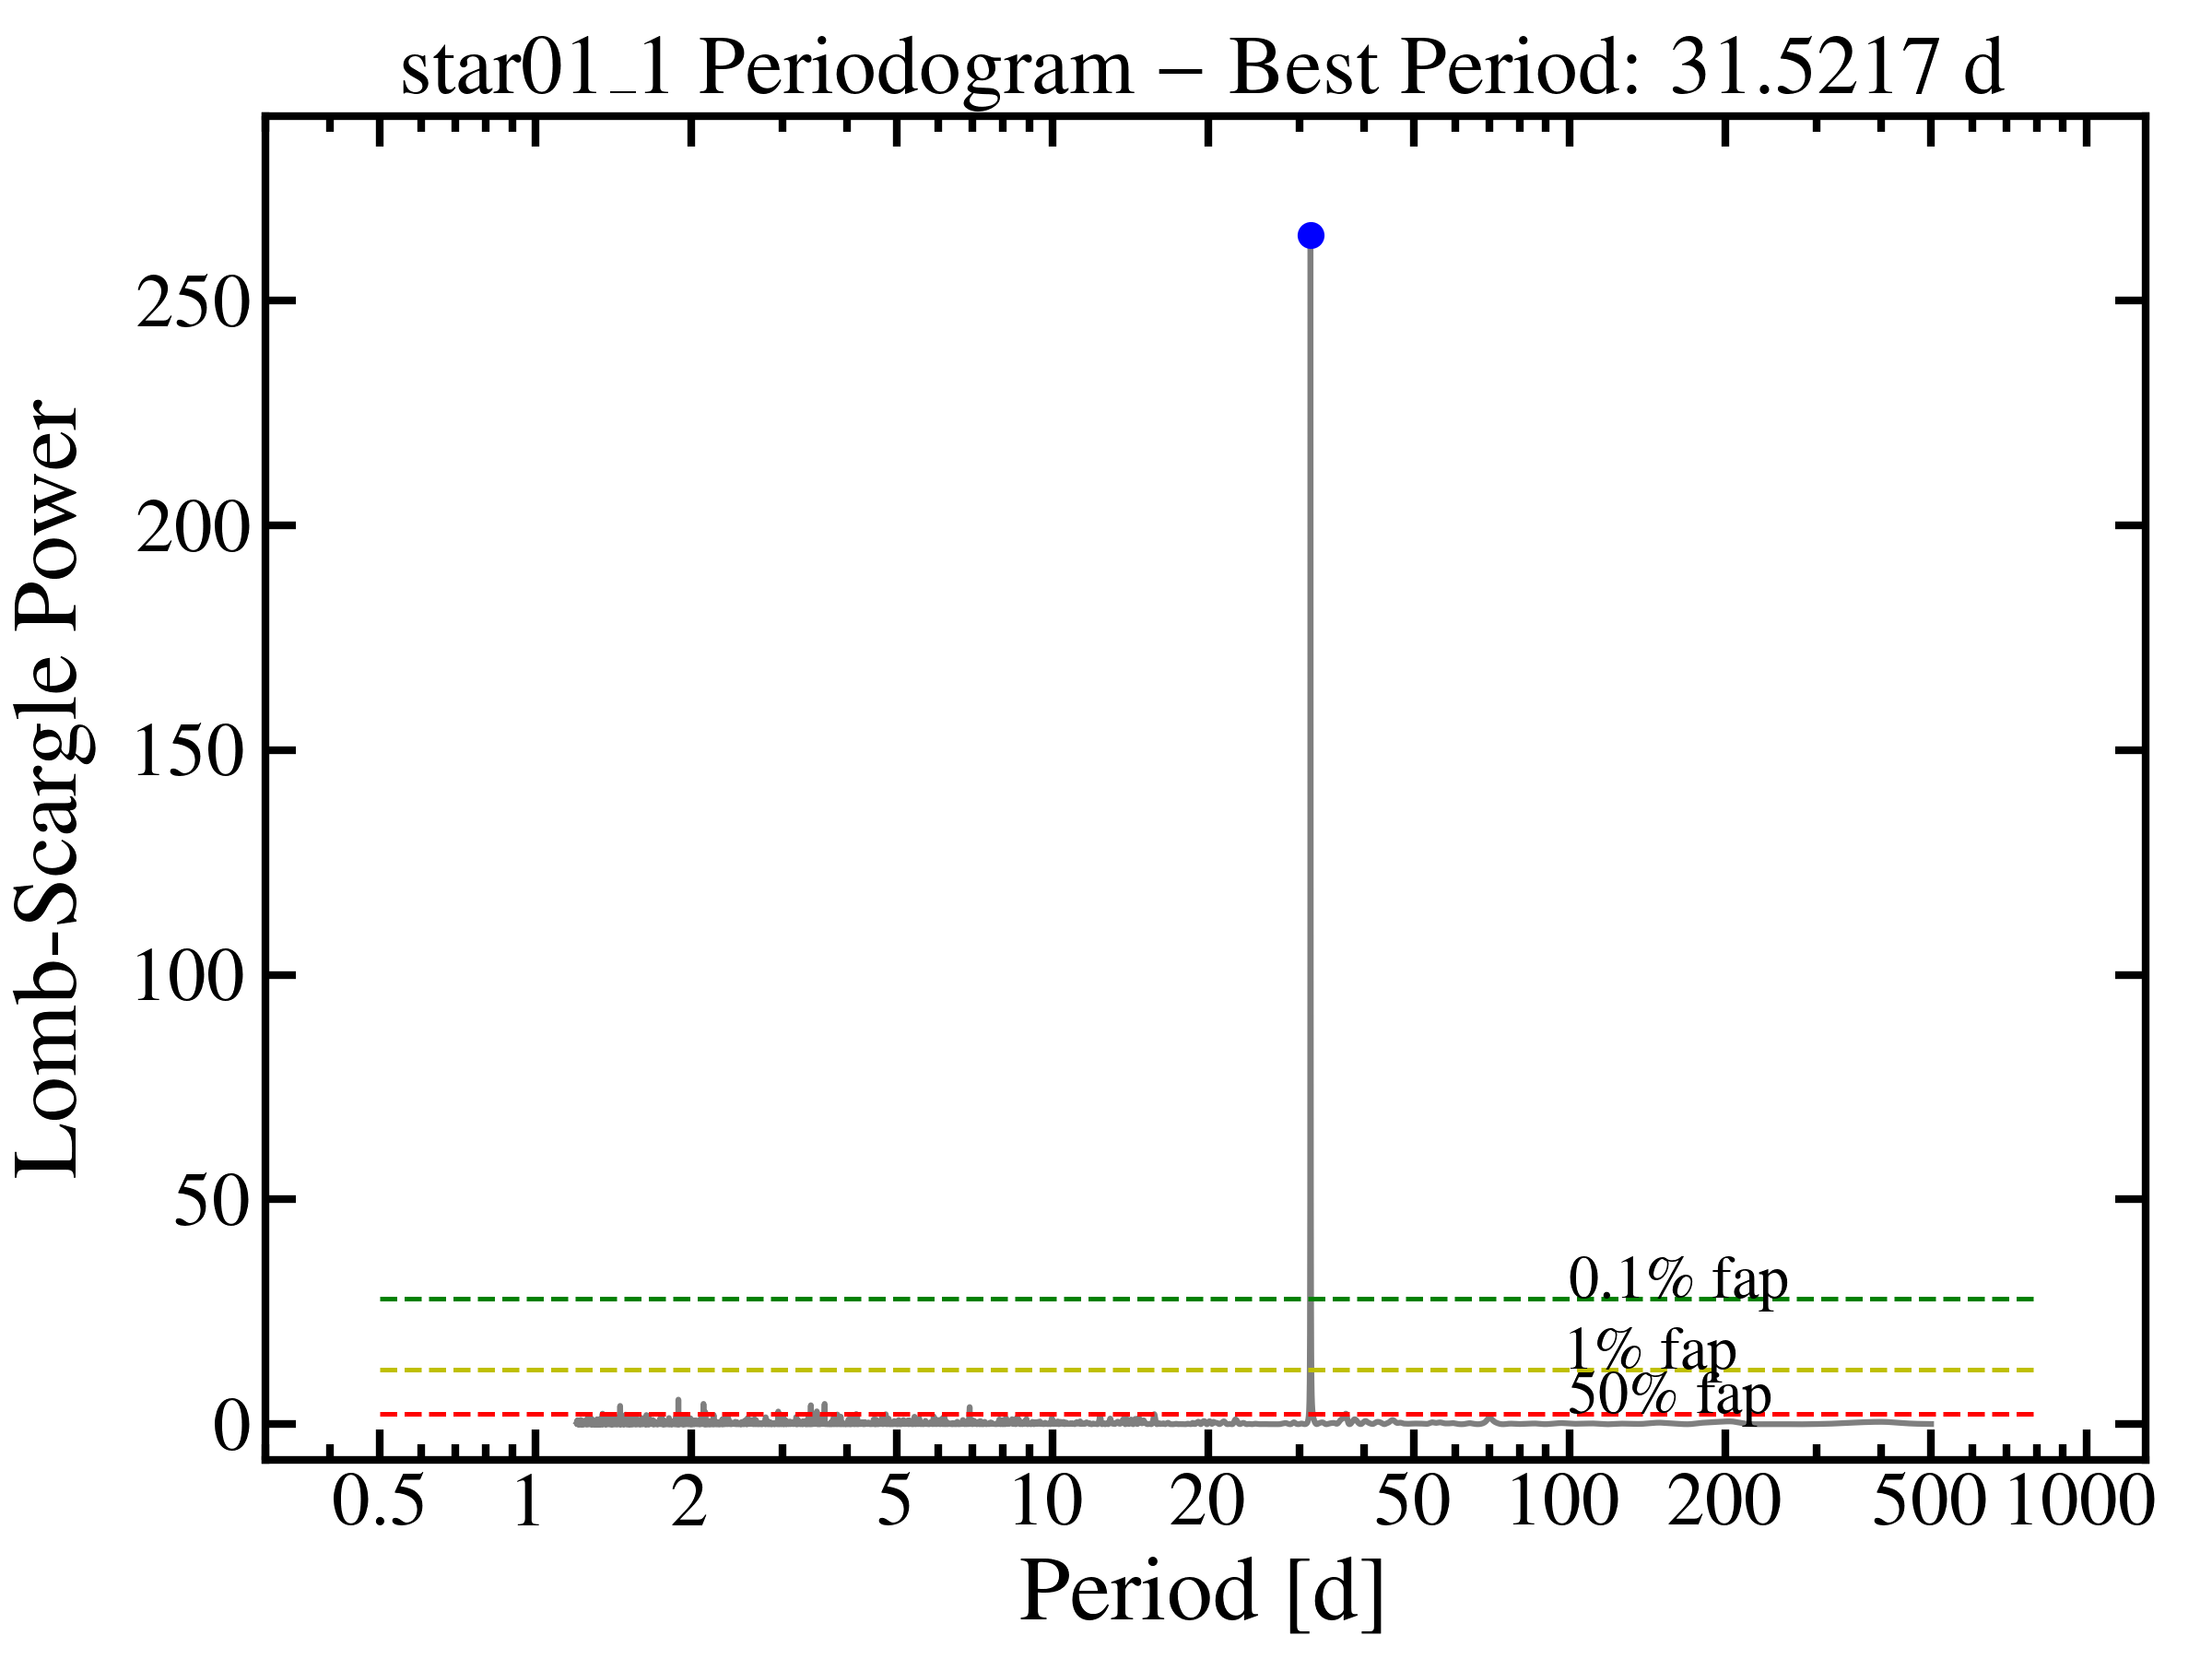

In [115]:
display(Image(
    filename='ravel_tutorial/SB1/LS/LS_star01_1_period_primary_12_epochs.png',
    width=600  # pixels
))

We have recovered the correct period of the system and with only 12 epochs!
However, keep in mind that higher mass ratios, low S/N, higher rotation, eccentricity, and the number of epochs, can have an effect on your RV measurements and/or the orbital period determination.

We can also inspect the phased RV curve fitted with a sinusoidal model which is stored in `/LS`, just to see if the orbital period found makes sense for our data:

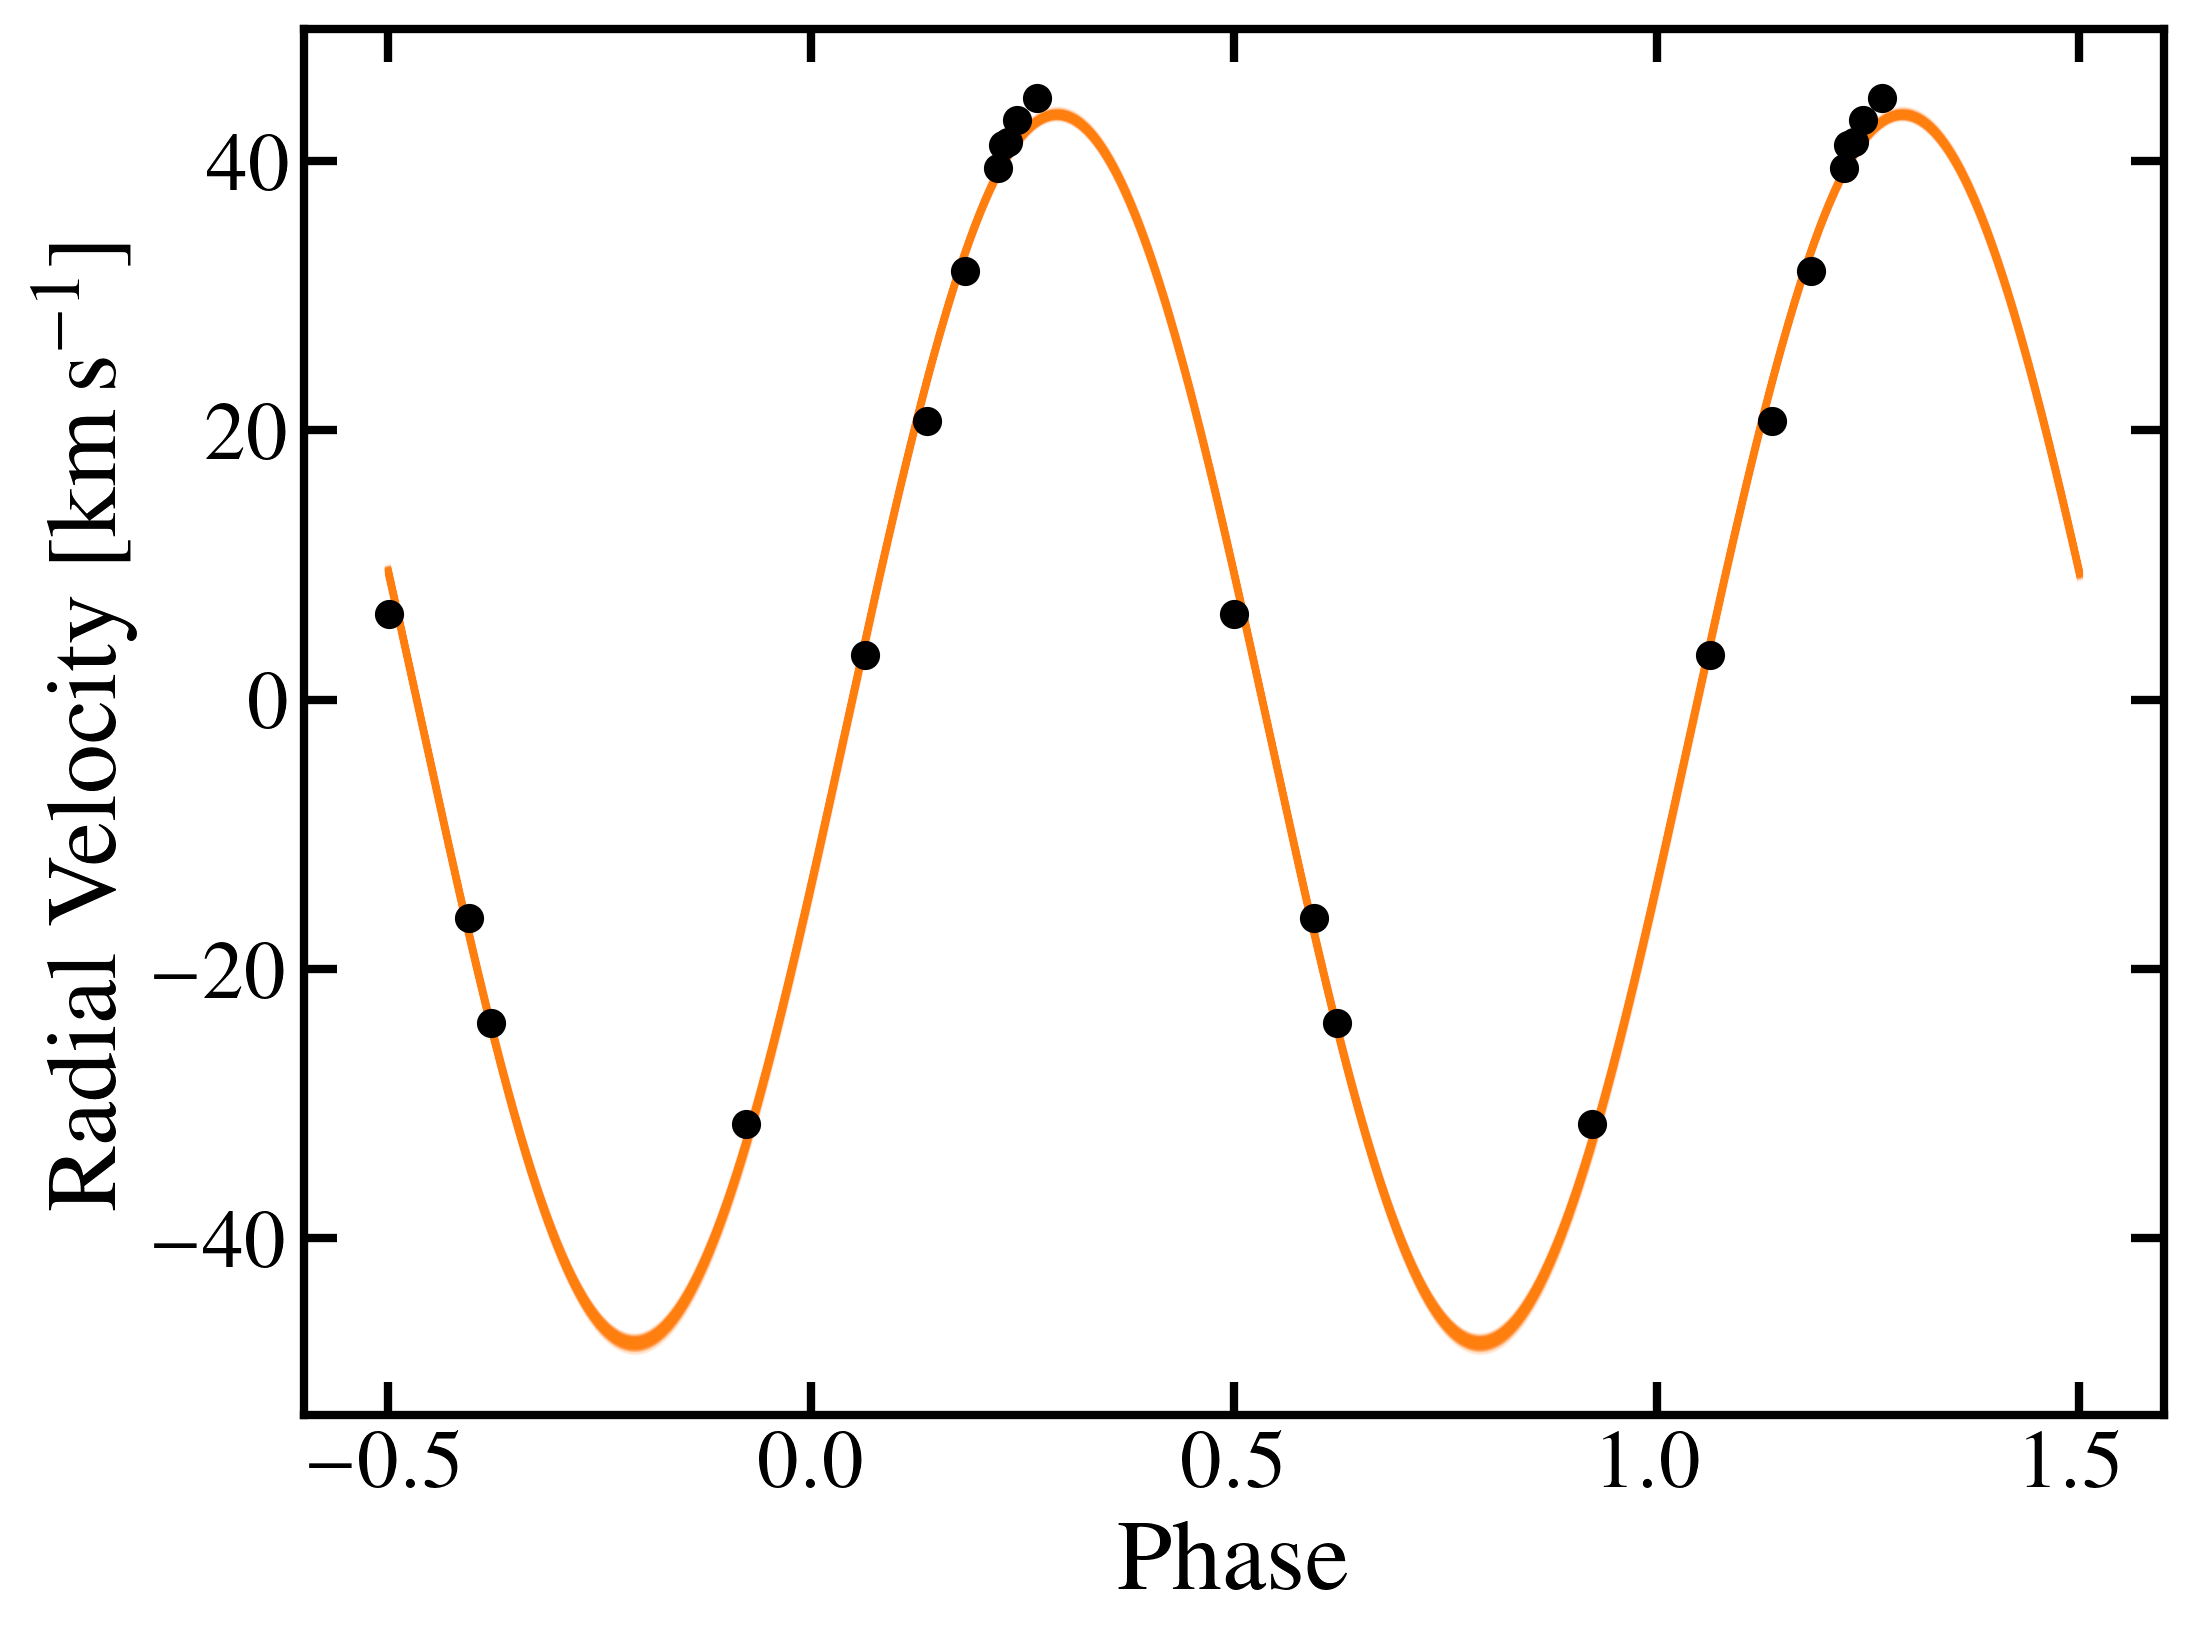

In [116]:
display(Image(
    filename='ravel_tutorial/SB1/LS/star01_1_sinu_fit_SB1_P=31.52.png',
    width=600  # pixels
))

---

### 8. Next Steps

For the case of high mass ratios, we'll explore SB2 fitting (`fit_sb2_probmod`) in the next tutorial.

Happy fitting!

